# Sinais e Sistemas: Resolução Detalhada de Exercícios (TP1)
**Unidade Curricular:** Sinais e Sistemas (SINSI)  
**Tópicos Abordados:**
1. **Paridade de Sinais:** Componente Par e Ímpar (Contínuo e Discreto)
2. **Energia e Potência:** Cálculo de $E_\infty$ e $P_\infty$, Classificação de Sinais
3. **Periodicidade:** Análise e determinação de Período Fundamental ($T_0$ / $N_0$)
4. **Componente Contínua (DC) e Alternada (AC):** Valor Médio, Potência Média e Valor Eficaz (RMS)

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# Configurações visuais dos gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (10, 4.5)
plt.rcParams['lines.linewidth'] = 2

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!



## 1. Paridade de Sinais

### Enquadramento Teórico
Qualquer sinal $x(t)$ (tempo contínuo) ou $x[n]$ (tempo discreto) pode ser decomposto unicamente na soma de uma componente **par** ($x_p$) e uma componente **ímpar** ($x_i$):

$$x(t) = x_p(t) + x_i(t)$$

onde:
* **Componente Par:** $x_p(t) = \mathcal{Ev}\{x(t)\} = \frac{x(t) + x(-t)}{2}$, satisfazendo $x_p(-t) = x_p(t)$
* **Componente Ímpar:** $x_i(t) = \mathcal{Od}\{x(t)\} = \frac{x(t) - x(-t)}{2}$, satisfazendo $x_i(-t) = -x_i(t)$

Para tempo discreto, as relações são análogas:
$$x_p[n] = \frac{x[n] + x[-n]}{2}, \quad x_i[n] = \frac{x[n] - x[-n]}{2}$$

### Exercício 2
**Enunciado:** Dado o sinal $x(t) = 4 e^{-t/2} u(t)$, calcule as suas componentes par e ímpar.

---
#### Resolução Analítica:
1. **Sinal original e inversão temporal:**
   $$x(t) = 4 e^{-t/2} u(t)$$
   $$x(-t) = 4 e^{-(-t)/2} u(-t) = 4 e^{t/2} u(-t)$$
   onde $u(t) = 1$ para $t \ge 0$ ($0$ para $t < 0$) e $u(-t) = 1$ para $t \le 0$ ($0$ para $t > 0$).

2. **Componente Par $x_p(t)$:**
   $$x_p(t) = \frac{x(t) + x(-t)}{2} = \frac{4 e^{-t/2} u(t) + 4 e^{t/2} u(-t)}{2} = 2 e^{-t/2} u(t) + 2 e^{t/2} u(-t)$$
   Analisando por ramos:
   - Para $t > 0$: $u(t) = 1$ e $u(-t) = 0 \implies x_p(t) = 2 e^{-t/2}$
   - Para $t < 0$: $u(t) = 0$ e $u(-t) = 1 \implies x_p(t) = 2 e^{t/2}$
   - Para $t = 0$: $x_p(0) = \frac{4 e^0(1) + 4 e^0(1)}{2} = 4$

   Expressão compacta:
   $$x_p(t) = 2 e^{-|t|/2}$$

3. **Componente Ímpar $x_i(t)$:**
   $$x_i(t) = \frac{x(t) - x(-t)}{2} = \frac{4 e^{-t/2} u(t) - 4 e^{t/2} u(-t)}{2} = 2 e^{-t/2} u(t) - 2 e^{t/2} u(-t)$$
   Analisando por ramos:
   - Para $t > 0$: $x_i(t) = 2 e^{-t/2}$
   - Para $t < 0$: $x_i(t) = -2 e^{t/2}$
   - Para $t = 0$: $x_i(0) = \frac{4 - 4}{2} = 0$

   Expressão compacta:
   $$x_i(t) = 2 \operatorname{sgn}(t) e^{-|t|/2} \quad (\text{com } x_i(0) = 0)$$

4. **Verificação da Reconstrução:**
   $$x_p(t) + x_i(t) = \begin{cases} 2 e^{-t/2} + 2 e^{-t/2} = 4 e^{-t/2}, & t > 0 \\ 4 + 0 = 4, & t = 0 \\ 2 e^{t/2} - 2 e^{t/2} = 0, & t < 0 \end{cases} = x(t) \quad \checkmark$$

Erro máximo de reconstrução x(t) - (x_p(t) + x_i(t)): 0.00e+00



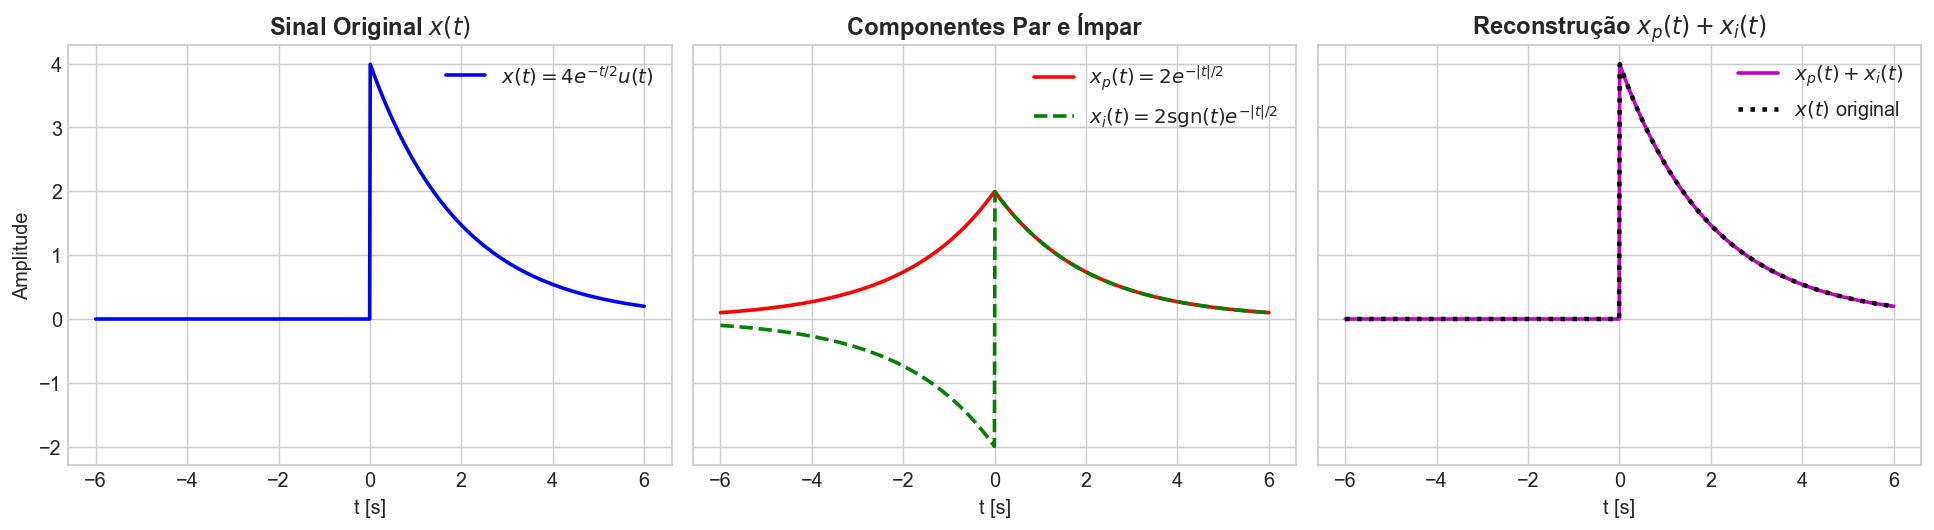

In [2]:
# Demonstração e Verificação Gráfica do Exercício 2
t = np.linspace(-6, 6, 1000)

# Sinal original x(t) = 4 * e^(-t/2) * u(t)
u_t = np.heaviside(t, 1.0)
u_minus_t = np.heaviside(-t, 1.0)

x = 4.0 * np.exp(-t / 2.0) * u_t
x_minus = 4.0 * np.exp(t / 2.0) * u_minus_t

# Componentes Par e Ímpar
x_p = 0.5 * (x + x_minus)
x_i = 0.5 * (x - x_minus)

# Reconstrução
x_rec = x_p + x_i

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)

axes[0].plot(t, x, 'b', label=r'$x(t) = 4 e^{-t/2} u(t)$')
axes[0].set_title('Sinal Original $x(t)$', fontweight='bold')
axes[0].set_xlabel('t [s]')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True)
axes[0].legend(loc='upper right')

axes[1].plot(t, x_p, 'r', label=r'$x_p(t) = 2 e^{-|t|/2}$')
axes[1].plot(t, x_i, 'g--', label=r'$x_i(t) = 2 \operatorname{sgn}(t) e^{-|t|/2}$')
axes[1].set_title('Componentes Par e Ímpar', fontweight='bold')
axes[1].set_xlabel('t [s]')
axes[1].grid(True)
axes[1].legend(loc='upper right')

axes[2].plot(t, x_rec, 'm', label=r'$x_p(t) + x_i(t)$')
axes[2].plot(t, x, 'k:', label=r'$x(t)$ original', linewidth=2.5)
axes[2].set_title('Reconstrução $x_p(t) + x_i(t)$', fontweight='bold')
axes[2].set_xlabel('t [s]')
axes[2].grid(True)
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

# Verificação do erro numérico absoluto máximo
erro_max = np.max(np.abs(x - x_rec))
print(f"Erro máximo de reconstrução x(t) - (x_p(t) + x_i(t)): {erro_max:.2e}")

### Exercício 5a
**Enunciado:** Represente graficamente as componentes par e ímpar para a sequência discreta:
$$x[n] = \begin{cases} -1, & n < 0 \\ 1, & n \ge 0 \end{cases}$$

---
#### Resolução Analítica:
1. **Expressão do sinal invertido temporalmente $x[-n]$:**
   - Para $n < 0 \implies -n > 0 \implies x[-n] = 1$
   - Para $n = 0 \implies -n = 0 \implies x[-0] = x[0] = 1$
   - Para $n > 0 \implies -n < 0 \implies x[-n] = -1$

2. **Componente Par $x_p[n]$:**
   $$x_p[n] = \frac{x[n] + x[-n]}{2}$$
   - Para $n < 0$: $x_p[n] = \frac{-1 + 1}{2} = 0$
   - Para $n = 0$: $x_p[0] = \frac{1 + 1}{2} = 1$
   - Para $n > 0$: $x_p[n] = \frac{1 + (-1)}{2} = 0$

   Logo, a componente par é um impulso unitário (delta de Kronecker):
   $$x_p[n] = \delta[n] = \begin{cases} 1, & n = 0 \\ 0, & n \neq 0 \end{cases}$$

3. **Componente Ímpar $x_i[n]$:**
   $$x_i[n] = \frac{x[n] - x[-n]}{2}$$
   - Para $n < 0$: $x_i[n] = \frac{-1 - 1}{2} = -1$
   - Para $n = 0$: $x_i[0] = \frac{1 - 1}{2} = 0$
   - Para $n > 0$: $x_i[n] = \frac{1 - (-1)}{2} = 1$

   Logo, a componente ímpar é a função sinal padrão:
   $$x_i[n] = \operatorname{sgn}[n] = \begin{cases} -1, & n < 0 \\ 0, & n = 0 \\ 1, & n > 0 \end{cases}$$

4. **Verificação da Reconstrução:**
   $$x_p[n] + x_i[n] = \delta[n] + \operatorname{sgn}[n] = \begin{cases} 0 + (-1) = -1, & n < 0 \\ 1 + 0 = 1, & n = 0 \\ 0 + 1 = 1, & n > 0 \end{cases} = x[n] \quad \checkmark$$

Valores de x_p[n]: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
Valores de x_i[n]: [-1. -1. -1. -1. -1. -1.  0.  1.  1.  1.  1.  1.  1.]



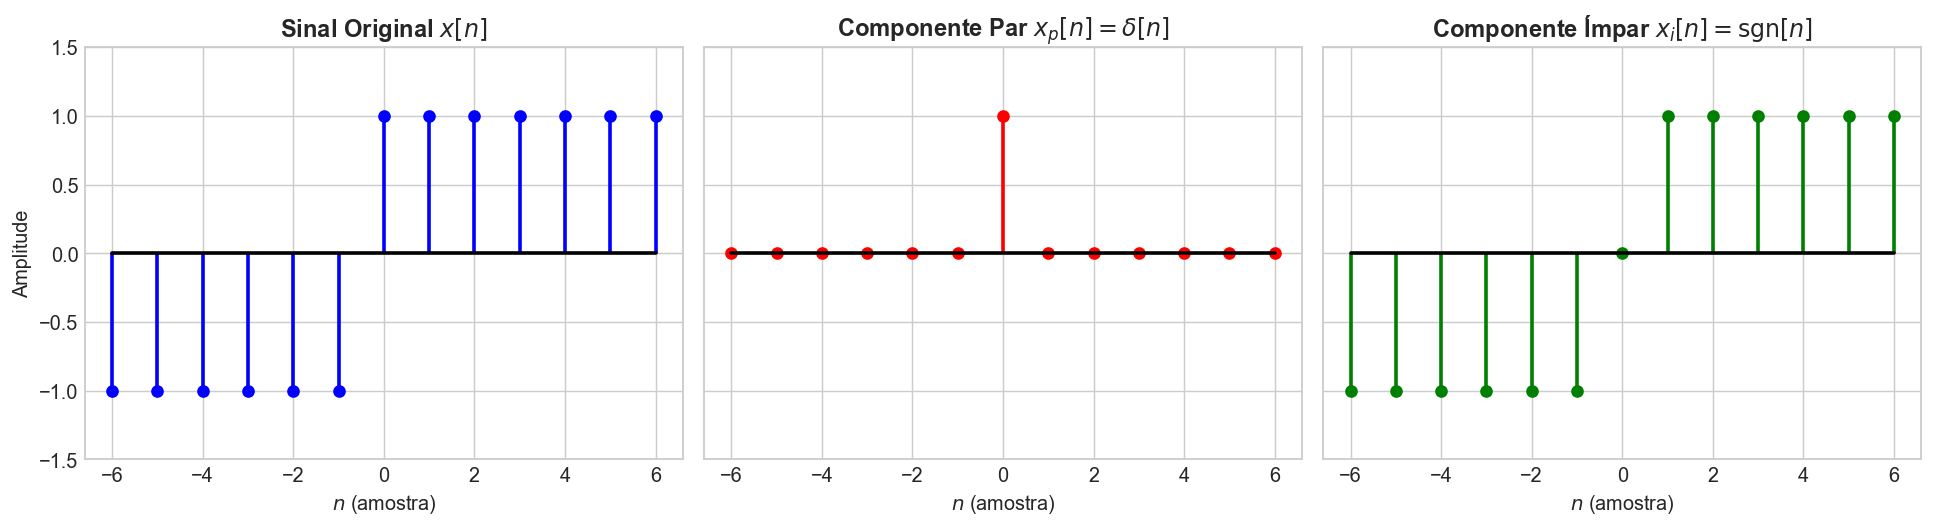

In [3]:
# Resolução Gráfica do Exercício 5a
n = np.arange(-6, 7)

# Definição do sinal x[n] = -1 para n < 0; 1 para n >= 0
x_disc = np.where(n >= 0, 1.0, -1.0)

# Sinal invertido temporalmente x[-n]
x_minus_disc = np.zeros_like(n, dtype=float)
for i, val in enumerate(n):
    idx = np.where(n == -val)[0][0]
    x_minus_disc[i] = x_disc[idx]

# Componentes Par e Ímpar
x_p_disc = 0.5 * (x_disc + x_minus_disc)
x_i_disc = 0.5 * (x_disc - x_minus_disc)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)

# Plot Original
markerline, stemlines, baseline = axes[0].stem(n, x_disc, linefmt='b-', markerfmt='bo', basefmt='k-')
axes[0].set_title(r'Sinal Original $x[n]$', fontweight='bold')
axes[0].set_xlabel('$n$ (amostra)')
axes[0].set_ylabel('Amplitude')
axes[0].set_ylim(-1.5, 1.5)
axes[0].grid(True)

# Plot Componente Par
markerline, stemlines, baseline = axes[1].stem(n, x_p_disc, linefmt='r-', markerfmt='ro', basefmt='k-')
axes[1].set_title(r'Componente Par $x_p[n] = \delta[n]$', fontweight='bold')
axes[1].set_xlabel('$n$ (amostra)')
axes[1].grid(True)

# Plot Componente Ímpar
markerline, stemlines, baseline = axes[2].stem(n, x_i_disc, linefmt='g-', markerfmt='go', basefmt='k-')
axes[2].set_title(r'Componente Ímpar $x_i[n] = \operatorname{sgn}[n]$', fontweight='bold')
axes[2].set_xlabel('$n$ (amostra)')
axes[2].grid(True)

plt.tight_layout()
plt.show()

print("Valores de x_p[n]:", x_p_disc)
print("Valores de x_i[n]:", x_i_disc)

## 2. Energia e Potência de Sinais

### Enquadramento Teórico
* **Sinais Contínuos:**
  - **Energia Total ($E_\infty$):**
    $$E_\infty = \int_{-\infty}^{+\infty} |x(t)|^2 \, dt$$
  - **Potência Média ($P_\infty$):**
    $$P_\infty = \lim_{T \to \infty} \frac{1}{2T} \int_{-T}^{+T} |x(t)|^2 \, dt$$

* **Sinais Discretos:**
  - **Energia Total ($E_\infty$):**
    $$E_\infty = \sum_{n=-\infty}^{+\infty} |x[n]|^2$$
  - **Potência Média ($P_\infty$):**
    $$P_\infty = \lim_{N \to \infty} \frac{1}{2N + 1} \sum_{n=-N}^{+N} |x[n]|^2$$
  - Se $x[n]$ for periódico com período fundamental $N_0$:
    $$P = \frac{1}{N_0} \sum_{n=0}^{N_0-1} |x[n]|^2$$

### Classificação de Sinais:
1. **Sinal de Energia:** $0 < E_\infty < \infty \implies P_\infty = 0$
2. **Sinal de Potência:** $E_\infty = \infty \implies 0 < P_\infty < \infty$
3. **Nem de Energia nem de Potência:** $E_\infty = \infty$ e $P_\infty = \infty$ ou $E_\infty = \infty$ e $P_\infty = 0$.

### Exercício 7a
**Enunciado:** Determine os valores de energia ($E_\infty$) e potência ($P_\infty$) para o sinal:
$$x_1(t) = e^{-2t} u(t)$$

---
#### Resolução Analítica:
1. **Cálculo da Energia $E_\infty$:**
   $$E_\infty = \int_{-\infty}^{+\infty} |x_1(t)|^2 \, dt = \int_{0}^{+\infty} \left(e^{-2t}\right)^2 \, dt = \int_{0}^{+\infty} e^{-4t} \, dt$$
   Primitivando:
   $$E_\infty = \left[ -\frac{1}{4} e^{-4t} \right]_{0}^{+\infty} = \left( 0 - \left(-\frac{1}{4} e^0\right) \right) = \frac{1}{4} \text{ J} = 0.25 \text{ J}$$

2. **Cálculo da Potência Média $P_\infty$:**
   Como a energia total é finita ($E_\infty = 0.25 < \infty$):
   $$P_\infty = \lim_{T \to \infty} \frac{1}{2T} \int_{-T}^{T} |x_1(t)|^2 dt = \lim_{T \to \infty} \frac{E_\infty}{2T} = \lim_{T \to \infty} \frac{1/4}{2T} = 0 \text{ W}$$

**Classificação:** $x_1(t)$ é um **Sinal de Energia**.

Energia Simbólica E_inf = 1/4 J (ou 0.2500 J)
Potência Média Simbólica P_inf = 0 W



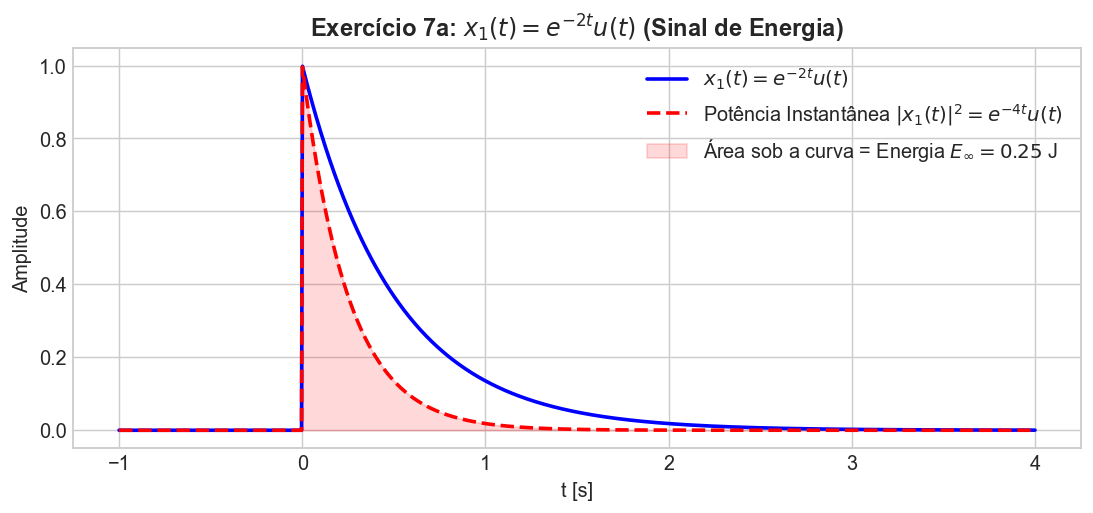

In [4]:
# Resolução Simbólica e Numérica do Exercício 7a com SymPy
t_sym = sp.symbols('t', real=True)
T_sym = sp.symbols('T', real=True, positive=True)

x1_sym = sp.exp(-2 * t_sym)

# Cálculo simbólico de E_infty
E_infty_sym = sp.integrate(x1_sym**2, (t_sym, 0, sp.oo))
print(f"Energia Simbólica E_inf = {E_infty_sym} J (ou {float(E_infty_sym):.4f} J)")

# Cálculo de P_infty através do limite
E_T = sp.integrate(x1_sym**2, (t_sym, 0, T_sym))
P_infty_sym = sp.limit(E_T / (2 * T_sym), T_sym, sp.oo)
print(f"Potência Média Simbólica P_inf = {P_infty_sym} W")

# Gráfico do sinal e da densidade de energia instantânea |x(t)|^2
t_vals = np.linspace(-1, 4, 1000)
x1_vals = np.where(t_vals >= 0, np.exp(-2 * t_vals), 0)
p_inst = x1_vals ** 2

plt.figure(figsize=(10, 4))
plt.plot(t_vals, x1_vals, 'b-', label=r'$x_1(t) = e^{-2t}u(t)$')
plt.plot(t_vals, p_inst, 'r--', label=r'Potência Instantânea $|x_1(t)|^2 = e^{-4t}u(t)$')
plt.fill_between(t_vals[t_vals >= 0], p_inst[t_vals >= 0], color='red', alpha=0.15, label=r'Área sob a curva = Energia $E_\infty = 0.25$ J')
plt.title(r'Exercício 7a: $x_1(t) = e^{-2t}u(t)$ (Sinal de Energia)', fontweight='bold')
plt.xlabel('t [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()

### Exercício 7i
**Enunciado:** Determine os valores de energia ($E_\infty$) e potência ($P_\infty$) para o sinal:
$$x_2[n] = e^{j\left(\frac{\pi}{2}n + \frac{\pi}{8}\right)}$$

---
#### Resolução Analítica:
1. **Magnitude do sinal:**
   Pela identidade de Euler, para qualquer fase real $\theta[n] = \frac{\pi}{2}n + \frac{\pi}{8}$:
   $$|x_2[n]| = \left|e^{j\theta[n]}\right| = \sqrt{\cos^2\theta[n] + \sin^2\theta[n]} = 1, \quad \forall n \in \mathbb{Z}$$

2. **Cálculo da Energia $E_\infty$:**
   $$E_\infty = \sum_{n=-\infty}^{+\infty} |x_2[n]|^2 = \sum_{n=-\infty}^{+\infty} 1^2 = \sum_{n=-\infty}^{+\infty} 1 = +\infty$$

3. **Cálculo da Potência Média $P_\infty$:**
   Como a frequência angular discreta é $\omega_0 = \frac{\pi}{2}$, o período fundamental em amostras é:
   $$N_0 = \frac{2\pi}{\omega_0} = \frac{2\pi}{\pi/2} = 4 \text{ amostras}$$
   
   Sendo o sinal periódico com período $N_0 = 4$, a potência média num período é:
   $$P_\infty = \frac{1}{N_0} \sum_{n=0}^{N_0 - 1} |x_2[n]|^2 = \frac{1}{4} \sum_{n=0}^{3} 1 = \frac{1}{4}(1 + 1 + 1 + 1) = \frac{4}{4} = 1 \text{ W}$$

**Classificação:** $x_2[n]$ é um **Sinal de Potência** ($E_\infty = \infty$ e $P_\infty = 1 \text{ W}$).

Módulo |x2[n]| constante: 1.00
Potência Média Numérica P = 1.0000 W



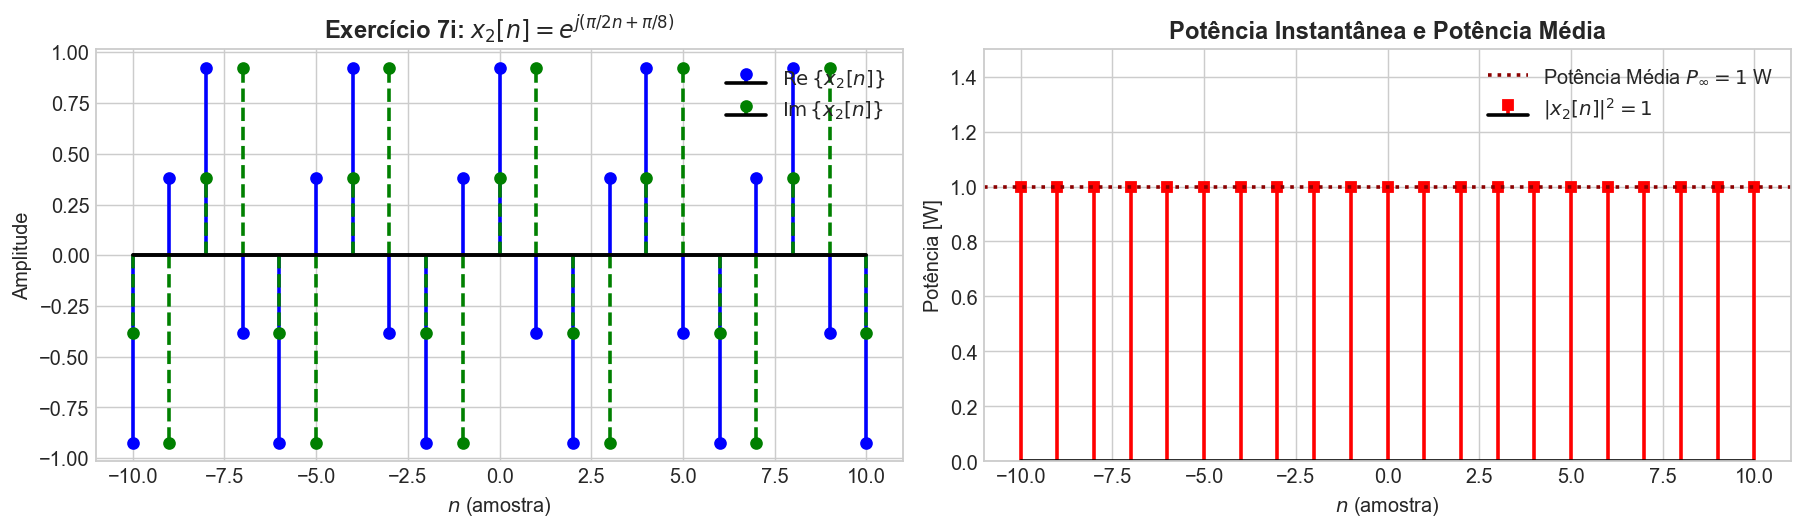

In [5]:
# Resolução e Simulação do Exercício 7i
n_disc = np.arange(-10, 11)
x2 = np.exp(1j * (np.pi / 2 * n_disc + np.pi / 8))

# Módulo e Potência Instantânea
mag_x2 = np.abs(x2)
p_inst_x2 = mag_x2 ** 2

# Potência Média calculada numericamente no intervalo
P_media_num = np.mean(p_inst_x2)

print(f"Módulo |x2[n]| constante: {mag_x2[0]:.2f}")
print(f"Potência Média Numérica P = {P_media_num:.4f} W")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))

# Parte Real e Imaginária
axes[0].stem(n_disc, np.real(x2), linefmt='b-', markerfmt='bo', basefmt='k-', label=r'$\operatorname{Re}\{x_2[n]\}$')
axes[0].stem(n_disc, np.imag(x2), linefmt='g--', markerfmt='go', basefmt='k-', label=r'$\operatorname{Im}\{x_2[n]\}$')
axes[0].set_title(r'Exercício 7i: $x_2[n] = e^{j(\pi/2 n + \pi/8)}$', fontweight='bold')
axes[0].set_xlabel('$n$ (amostra)')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True)
axes[0].legend(loc='upper right')

# Potência Instantânea |x2[n]|^2
axes[1].stem(n_disc, p_inst_x2, linefmt='r-', markerfmt='rs', basefmt='k-', label=r'$|x_2[n]|^2 = 1$')
axes[1].axhline(1.0, color='darkred', linestyle=':', label=r'Potência Média $P_\infty = 1$ W')
axes[1].set_title(r'Potência Instantânea e Potência Média', fontweight='bold')
axes[1].set_xlabel('$n$ (amostra)')
axes[1].set_ylabel('Potência [W]')
axes[1].set_ylim(0, 1.5)
axes[1].grid(True)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

## 3. Periodicidade de Sinais

### Enquadramento Teórico
* **Sinais Contínuos:**
  - $x(t)$ é periódico se existir $T > 0$ tal que $x(t + T) = x(t), \forall t$.
  - O período fundamental $T_0$ é o menor valor positivo de $T$.
  - Para sinais sinusoidais: $T_0 = \frac{2\pi}{\omega_0}$.
  - Para uma soma de sinais periódicos $x(t) = x_1(t) + x_2(t)$: $x(t)$ é periódico se e só se o quociente entre os períodos for um **número racional**:
    $$\frac{T_1}{T_2} = \frac{p}{q} \in \mathbb{Q} \quad (p, q \in \mathbb{Z}^+)$$
    Nesse caso, o período fundamental é $T_0 = q \cdot T_1 = p \cdot T_2 = \operatorname{mmc}(T_1, T_2)$.

* **Sinais Discretos:**
  - $x[n]$ é periódico se existir um inteiro $N > 0$ tal que $x[n + N] = x[n], \forall n \in \mathbb{Z}$.
  - Para $x[n] = \cos(\omega_0 n)$ ou $e^{j \omega_0 n}$, o sinal é periódico se e só se $\frac{\omega_0}{2\pi}$ for um **número racional**:
    $$\frac{\omega_0}{2\pi} = \frac{m}{N} \in \mathbb{Q} \quad (m, N \in \mathbb{Z}^+, \text{ com } \operatorname{mdc}(m, N) = 1)$$
    Nesse caso, o período fundamental é $N_0 = N = \frac{2\pi}{\omega_0} m$.

### Exercício 8c
**Enunciado:** Classifique o seguinte sinal quanto à periodicidade. Se for periódico, determine o seu período fundamental:
$$x_3(t) = \cos\left(\frac{\pi}{3}t\right) + \sin\left(\frac{\pi}{4}t\right)$$

---
#### Resolução Analítica:
1. **Identificação das componentes e seus períodos individuais:**
   - Componente 1: $x_{3a}(t) = \cos\left(\frac{\pi}{3}t\right)$
     - Frequência angular: $\omega_1 = \frac{\pi}{3} \text{ rad/s}$
     - Período fundamental: $T_1 = \frac{2\pi}{\omega_1} = \frac{2\pi}{\pi/3} = 6 \text{ s}$
   
   - Componente 2: $x_{3b}(t) = \sin\left(\frac{\pi}{4}t\right)$
     - Frequência angular: $\omega_2 = \frac{\pi}{4} \text{ rad/s}$
     - Período fundamental: $T_2 = \frac{2\pi}{\omega_2} = \frac{2\pi}{\pi/4} = 8 \text{ s}$

2. **Teste de Comensurabilidade (Racionalidade da razão dos períodos):**
   $$\frac{T_1}{T_2} = \frac{6}{8} = \frac{3}{4}$$
   Como $\frac{3}{4} \in \mathbb{Q}$ (é um número racional com $p=3$ e $q=4$ irredutíveis), o sinal composto $x_3(t)$ é **PERIÓDICO**.

3. **Cálculo do Período Fundamental $T_0$:**
   $$T_0 = q \cdot T_1 = p \cdot T_2 = 4 \times 6\text{ s} = 3 \times 8\text{ s} = 24 \text{ s}$$

   *(Em alternativa, via frequência angular fundamental $\omega_0$)*:
   $$\omega_0 = \operatorname{mdc}\left(\frac{\pi}{3}, \frac{\pi}{4}\right) = \frac{\pi}{12} \implies T_0 = \frac{2\pi}{\omega_0} = \frac{2\pi}{\pi/12} = 24\text{ s}$$

**Conclusão:** O sinal $x_3(t)$ é **Periódico** com período fundamental **$T_0 = 24\text{ s}$**.

Diferença máxima |x3(t + 24) - x3(t)|: 5.61e-15 (Perfeito)



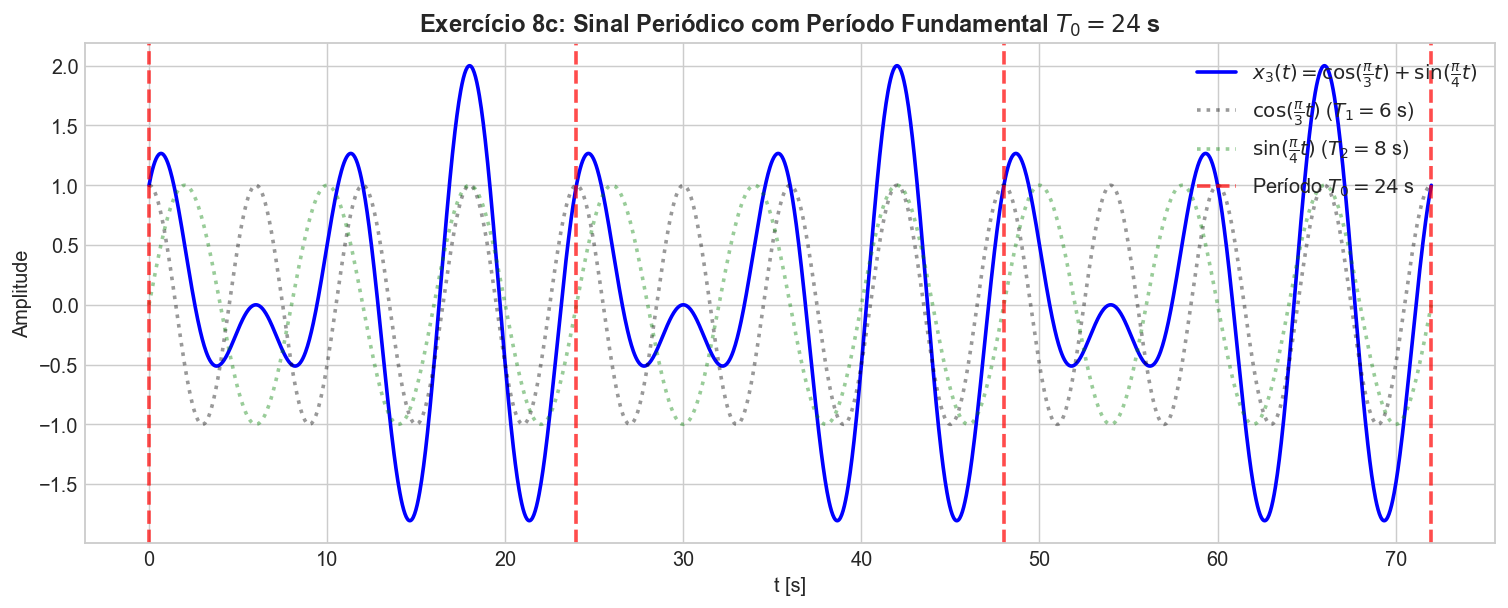

In [6]:
# Demonstração Gráfica do Exercício 8c: Sinal Periódico com T0 = 24s
T0 = 24.0
t_per = np.linspace(0, 3 * T0, 2000) # 3 períodos fundamentais completos

x3a = np.cos(np.pi / 3.0 * t_per)
x3b = np.sin(np.pi / 4.0 * t_per)
x3 = x3a + x3b

plt.figure(figsize=(14, 5))
plt.plot(t_per, x3, 'b-', label=r'$x_3(t) = \cos(\frac{\pi}{3}t) + \sin(\frac{\pi}{4}t)$')
plt.plot(t_per, x3a, 'k:', alpha=0.4, label=r'$\cos(\frac{\pi}{3}t)$ ($T_1=6$ s)')
plt.plot(t_per, x3b, 'g:', alpha=0.4, label=r'$\sin(\frac{\pi}{4}t)$ ($T_2=8$ s)')

# Linhas verticais a cada período fundamental T0 = 24s
for k in range(4):
    plt.axvline(k * T0, color='red', linestyle='--', alpha=0.7, label=f'Período $T_0={k*24}$ s' if k==1 else "")

plt.title(r'Exercício 8c: Sinal Periódico com Período Fundamental $T_0 = 24$ s', fontweight='bold')
plt.xlabel('t [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend(loc='upper right')
plt.show()

# Verificação numérica da periodicidade: x3(t + 24) == x3(t)
t_test = np.linspace(0, 10, 100)
x3_t = np.cos(np.pi / 3.0 * t_test) + np.sin(np.pi / 4.0 * t_test)
x3_t_plus_T0 = np.cos(np.pi / 3.0 * (t_test + 24)) + np.sin(np.pi / 4.0 * (t_test + 24))
diff_max = np.max(np.abs(x3_t - x3_t_plus_T0))
print(f"Diferença máxima |x3(t + 24) - x3(t)|: {diff_max:.2e} (Perfeito)")

### Exercício 8i
**Enunciado:** Classifique o seguinte sinal quanto à periodicidade. Se for periódico, determine o seu período fundamental:
$$x_1[n] = \cos\left(\frac{n}{4}\right)$$

---
#### Resolução Analítica:
1. **Identificação da frequência angular discreta:**
   $$x_1[n] = \cos(\omega_0 n) \implies \omega_0 = \frac{1}{4} \text{ rad/amostra}$$

2. **Condição de Periodicidade em Tempo Discreto:**
   Para que um sinal sinusoidal discreto seja periódico, a frequência normalizada $\frac{\omega_0}{2\pi}$ deve ser uma fração de inteiros (número racional):
   $$\frac{\omega_0}{2\pi} = \frac{1/4}{2\pi} = \frac{1}{8\pi}$$

3. **Verificação:**
   Como $\pi$ é um número irracional, $\frac{1}{8\pi} \notin \mathbb{Q}$. Logo, não existem inteiros $m, N \in \mathbb{Z}^+$ tais que:
   $$\omega_0 N = 2\pi m \iff \frac{1}{4} N = 2\pi m \iff N = 8\pi m$$

**Conclusão:** O sinal $x_1[n]$ é **Aperiódico** (não periódico).

Frequência normalizada f0 = 1 / (8*pi) = 0.039788735772973836 (Irracional -> Aperiódico)



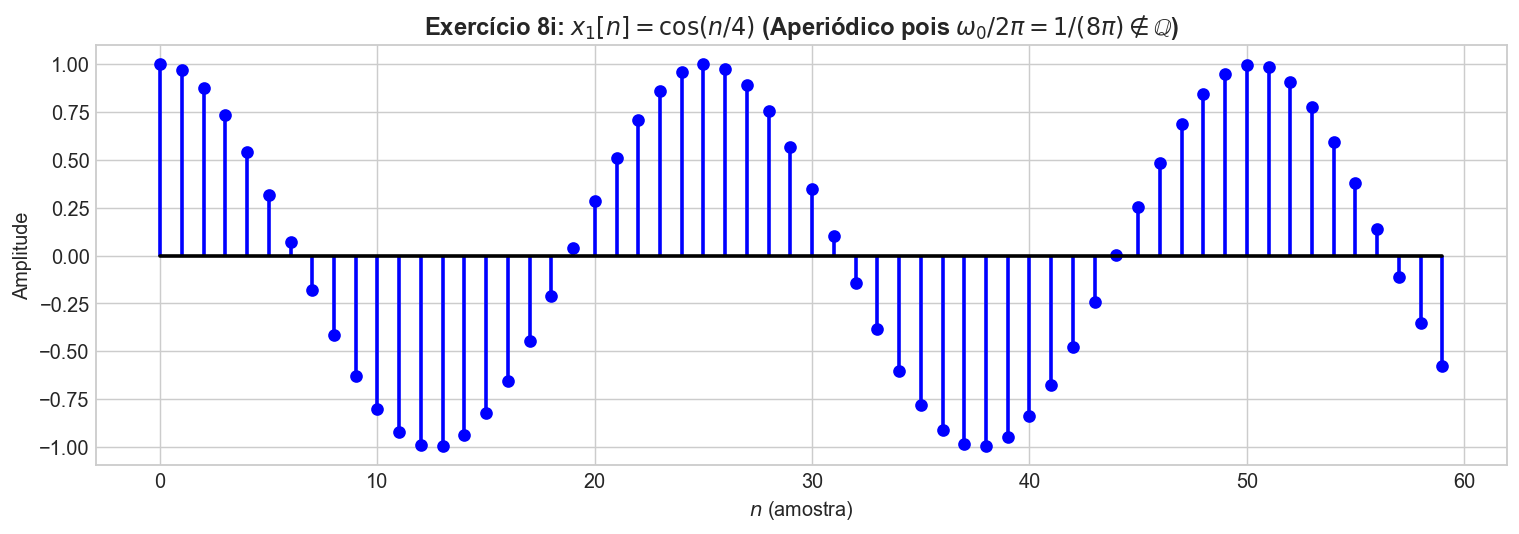

In [7]:
# Demonstração Gráfica do Exercício 8i: Sinal Discreto Aperiódico
n_pts = np.arange(0, 60)
x1_d = np.cos(n_pts / 4.0)

plt.figure(figsize=(14, 4.2))
markerline, stemlines, baseline = plt.stem(n_pts, x1_d, linefmt='b-', markerfmt='bo', basefmt='k-')
plt.title(r'Exercício 8i: $x_1[n] = \cos(n/4)$ (Aperiódico pois $\omega_0 / 2\pi = 1/(8\pi) \notin \mathbb{Q}$)', fontweight='bold')
plt.xlabel('$n$ (amostra)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

print("Frequência normalizada f0 = 1 / (8*pi) =", 1 / (8 * np.pi), "(Irracional -> Aperiódico)")

## 4. Componente Contínua, Alternada, Potência Média e Valor Eficaz

### Enquadramento Teórico
Dado um sinal periódico $x(t)$ de período fundamental $T_0$:

1. **Componente Contínua ($x_{DC}$ ou Valor Médio):**
   $$x_{DC} = \bar{x} = \langle x(t) \rangle = \frac{1}{T_0} \int_{T_0} x(t) \, dt$$

2. **Componente Alternada ($x_{AC}(t)$):**
   $$x_{AC}(t) = x(t) - x_{DC}$$
   Por definição, a média da componente alternada é nula: $\langle x_{AC}(t) \rangle = 0$.

3. **Potência Média Total ($P$):**
   $$P = \frac{1}{T_0} \int_{T_0} |x(t)|^2 \, dt$$
   Pelo teorema da ortogonalidade:
   $$P = P_{DC} + P_{AC} = x_{DC}^2 + \frac{1}{T_0} \int_{T_0} |x_{AC}(t)|^2 \, dt$$

4. **Valor Eficaz (RMS - *Root Mean Square*):**
   $$X_{rms} = x_{ef} = \sqrt{P} = \sqrt{\frac{1}{T_0} \int_{T_0} |x(t)|^2 \, dt} = \sqrt{x_{DC}^2 + X_{AC,rms}^2}$$

### Exercício 9b
**Enunciado:** Decomponha o seguinte sinal periódico nas suas componentes contínua e alternada e determine a sua potência média e o seu valor eficaz:
- $x(t) = 2$ entre $0$ e $1$
- $x(t) = -1$ entre $1$ e $4$
- Repete-se infinitamente (periódico de período $T_0 = 4$).

---
#### Resolução Analítica Passo a Passo:

1. **Definição do Período Fundamental:**
   O intervalo de um período completo é $[0, 4[$, logo:
   $$T_0 = 4 \text{ s}$$
   $$x(t) = \begin{cases} 2, & 0 \le t < 1 \\ -1, & 1 \le t < 4 \end{cases}$$

2. **Componente Contínua ($x_{DC}$):**
   $$x_{DC} = \frac{1}{T_0} \int_{0}^{T_0} x(t) \, dt = \frac{1}{4} \left( \int_{0}^{1} 2 \, dt + \int_{1}^{4} (-1) \, dt \right)$$
   $$x_{DC} = \frac{1}{4} \Big( 2(1 - 0) + (-1)(4 - 1) \Big) = \frac{1}{4} (2 - 3) = -\frac{1}{4} = -0.25$$

3. **Componente Alternada ($x_{AC}(t) = x(t) - x_{DC}$):**
   - Para $0 \le t < 1$:
     $$x_{AC}(t) = 2 - (-0.25) = 2.25 = \frac{9}{4}$$
   - Para $1 \le t < 4$:
     $$x_{AC}(t) = -1 - (-0.25) = -0.75 = -\frac{3}{4}$$

   *(Verificação da média de $x_{AC}$: $\frac{1}{4}(2.25 \times 1 + (-0.75) \times 3) = \frac{1}{4}(2.25 - 2.25) = 0$ $\checkmark$)*

4. **Potência Média ($P$):**
   $$P = \frac{1}{T_0} \int_{0}^{T_0} |x(t)|^2 \, dt = \frac{1}{4} \left( \int_{0}^{1} 2^2 \, dt + \int_{1}^{4} (-1)^2 \, dt \right)$$
   $$P = \frac{1}{4} \Big( 4(1) + 1(3) \Big) = \frac{4 + 3}{4} = \frac{7}{4} = 1.75 \text{ W}$$

   *Verificação por decomposição $P = P_{DC} + P_{AC}$:*
   - $P_{DC} = x_{DC}^2 = \left(-\frac{1}{4}\right)^2 = \frac{1}{16} = 0.0625 \text{ W}$
   - $P_{AC} = \frac{1}{4} \left( \left(\frac{9}{4}\right)^2 \times 1 + \left(-\frac{3}{4}\right)^2 \times 3 \right) = \frac{1}{4} \left( \frac{81}{16} + \frac{27}{16} \right) = \frac{108}{64} = \frac{27}{16} = 1.6875 \text{ W}$
   - $P = \frac{1}{16} + \frac{27}{16} = \frac{28}{16} = \frac{7}{4} = 1.75 \text{ W}$ $\checkmark$

5. **Valor Eficaz ($X_{rms}$):**
   $$X_{rms} = \sqrt{P} = \sqrt{\frac{7}{4}} = \frac{\sqrt{7}}{2} \approx 1.322876$$

--- RESULTADOS ANALÍTICOS VS NUMÉRICOS ---
Componente DC (x_DC) : Analítico = -0.2500 | Numérico = -0.2500
Potência Média (P)   : Analítico = 1.7500 W (7/4) | Numérico = 1.7500 W
Potência DC (P_DC)   : Analítico = 0.0625 W (1/16)
Potência AC (P_AC)   : Analítico = 1.6875 W (27/16)
Valor Eficaz (X_rms) : Analítico = 1.322876 (sqrt(7)/2) | Numérico = 1.322876



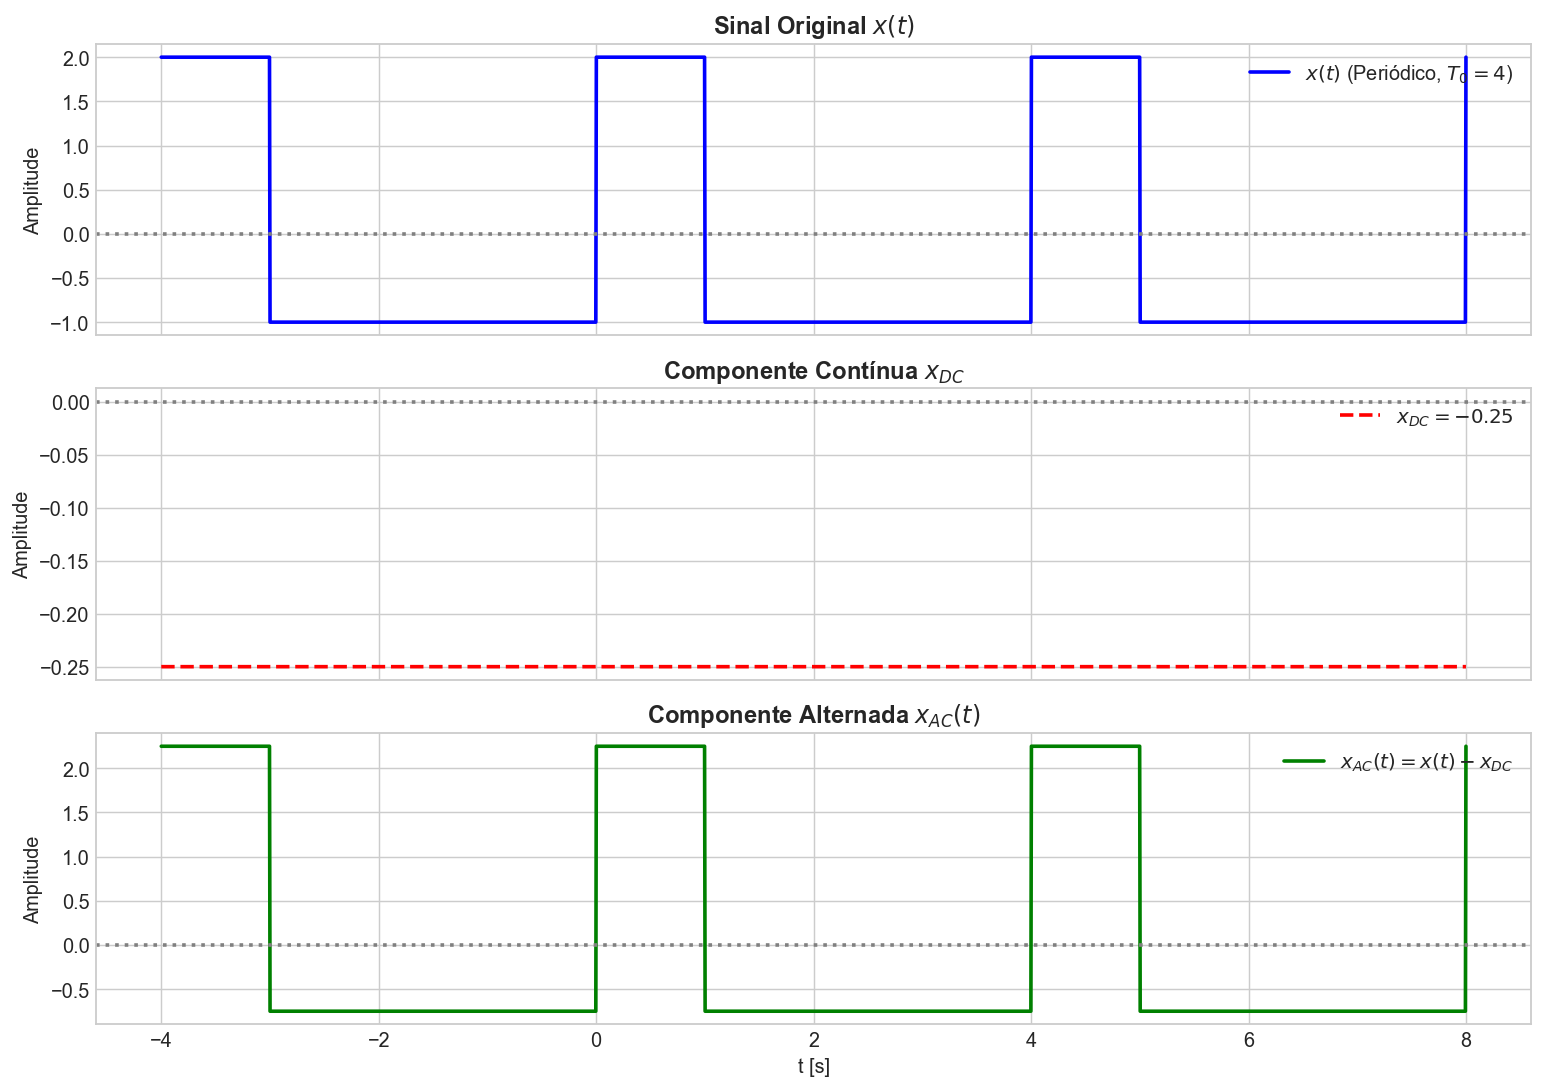

In [8]:
# Resolução e Verificação Numérica do Exercício 9b
T0 = 4.0
t_wave = np.linspace(-4, 8, 2400) # 3 períodos completos

def x_periodic(t):
    # Reduzir t ao intervalo base [0, 4[
    t_mod = np.mod(t, T0)
    return np.where(t_mod < 1.0, 2.0, -1.0)

x_vals = x_periodic(t_wave)

# Cálculos
x_dc = -1/4
x_ac_vals = x_vals - x_dc

P_total = 7/4
P_dc = x_dc ** 2
P_ac = 27/16
X_rms = np.sqrt(P_total)

# Verificação numérica por integração trapezoidal num período [0, 4]
t_one_period = np.linspace(0, 4, 10000, endpoint=False)
x_one = x_periodic(t_one_period)

x_dc_num = np.mean(x_one)
P_num = np.mean(x_one ** 2)
X_rms_num = np.sqrt(P_num)

print("--- RESULTADOS ANALÍTICOS VS NUMÉRICOS ---")
print(f"Componente DC (x_DC) : Analítico = {x_dc:.4f} | Numérico = {x_dc_num:.4f}")
print(f"Potência Média (P)   : Analítico = {P_total:.4f} W (7/4) | Numérico = {P_num:.4f} W")
print(f"Potência DC (P_DC)   : Analítico = {P_dc:.4f} W (1/16)")
print(f"Potência AC (P_AC)   : Analítico = {P_ac:.4f} W (27/16)")
print(f"Valor Eficaz (X_rms) : Analítico = {X_rms:.6f} (sqrt(7)/2) | Numérico = {X_rms_num:.6f}")

# Gráficos da Decomposição
fig, axes = plt.subplots(3, 1, figsize=(12, 8.5), sharex=True)

# Sinal Total
axes[0].plot(t_wave, x_vals, 'b-', label=r'$x(t)$ (Periódico, $T_0=4$)')
axes[0].axhline(0, color='gray', linestyle=':')
axes[0].set_ylabel('Amplitude')
axes[0].set_title(r'Sinal Original $x(t)$', fontweight='bold')
axes[0].grid(True)
axes[0].legend(loc='upper right')

# Componente DC
axes[1].plot(t_wave, np.full_like(t_wave, x_dc), 'r--', label=r'$x_{DC} = -0.25$')
axes[1].axhline(0, color='gray', linestyle=':')
axes[1].set_ylabel('Amplitude')
axes[1].set_title(r'Componente Contínua $x_{DC}$', fontweight='bold')
axes[1].grid(True)
axes[1].legend(loc='upper right')

# Componente AC
axes[2].plot(t_wave, x_ac_vals, 'g-', label=r'$x_{AC}(t) = x(t) - x_{DC}$')
axes[2].axhline(0, color='gray', linestyle=':')
axes[2].set_xlabel('t [s]')
axes[2].set_ylabel('Amplitude')
axes[2].set_title(r'Componente Alternada $x_{AC}(t)$', fontweight='bold')
axes[2].grid(True)
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

## Resumo Consolidado dos Resultados

| Exercício | Tópico | Expressão / Sinal Atualizado | Resposta / Conclusão Principal |
| :--- | :--- | :--- | :--- |
| **2** | Paridade (Contínuo) | $x(t) = 4 e^{-t/2} u(t)$ | $x_p(t) = 2 e^{-|t|/2}$, $x_i(t) = 2\operatorname{sgn}(t) e^{-|t|/2}$ |
| **5a** | Paridade (Discreto) | $x[n] = \begin{cases} -1, & n < 0 \\ 1, & n \ge 0 \end{cases}$ | $x_p[n] = \delta[n]$ (Impulso em $n=0$), $x_i[n] = \operatorname{sgn}[n]$ |
| **7a** | Energia e Potência | $x_1(t) = e^{-2t} u(t)$ | $E_\infty = \frac{1}{4} \text{ J} = 0.25\text{ J}$, $P_\infty = 0\text{ W}$ (Sinal de Energia) |
| **7i** | Energia e Potência | $x_2[n] = e^{j(\pi/2 n + \pi/8)}$ | $E_\infty = \infty$, $P_\infty = 1\text{ W}$ (Sinal de Potência, $N_0 = 4$) |
| **8c** | Periodicidade | $x_3(t) = \cos(\frac{\pi}{3}t) + \sin(\frac{\pi}{4}t)$ | **Periódico** com $T_0 = 24\text{ s}$ ($T_1/T_2 = 6/8 = 3/4 \in \mathbb{Q}$) |
| **8i** | Periodicidade | $x_1[n] = \cos(n/4)$ | **Aperiódico** ($\omega_0/(2\pi) = 1/(8\pi) \notin \mathbb{Q}$) |
| **9b** | DC / AC / RMS | $x(t) = \begin{cases} 2, & 0 \le t < 1 \\ -1, & 1 \le t < 4 \end{cases}$ ($T_0=4$) | $x_{DC} = -\frac{1}{4}$, $x_{AC}(t) = \begin{cases} 2.25, & 0 \le t < 1 \\ -0.75, & 1 \le t < 4 \end{cases}$<br>$P = \frac{7}{4} = 1.75\text{ W}$, $X_{rms} = \frac{\sqrt{7}}{2} \approx 1.3229$ |